In [3]:
import ants
import torchio as tio
import torch
import matplotlib.pyplot as plt

mri_path = r"C:\Users\hp\Downloads\MSLUB-T1\patient30_T1W.nii.gz"
gt_path = r"C:\Users\hp\Downloads\MSLUB-GT\patient30_consensus_gt.nii.gz"

ants_image = ants.image_read(mri_path)
ants_gt = ants.image_read(gt_path)

reoriented_image = ants.reorient_image2(ants_image, orientation="RAS")
reoriented_gt = ants.reorient_image2(ants_gt, orientation="RAS")

torchio_image = tio.ScalarImage(tensor=torch.from_numpy(reoriented_image.numpy()).unsqueeze(0))
torchio_gt = tio.ScalarImage(tensor=torch.from_numpy(reoriented_gt.numpy()).unsqueeze(0))

resized_image = tio.Resize(target_shape=(128, 128, 128), image_interpolation="linear")(torchio_image)
resized_gt = tio.Resize(target_shape=(128, 128, 128), image_interpolation="linear")(torchio_gt)

print(f"Resized image shape: {resized_image.shape}")
print(f"Resized GT shape: {resized_gt.shape}")

Resized image shape: (1, 128, 128, 128)
Resized GT shape: (1, 128, 128, 128)


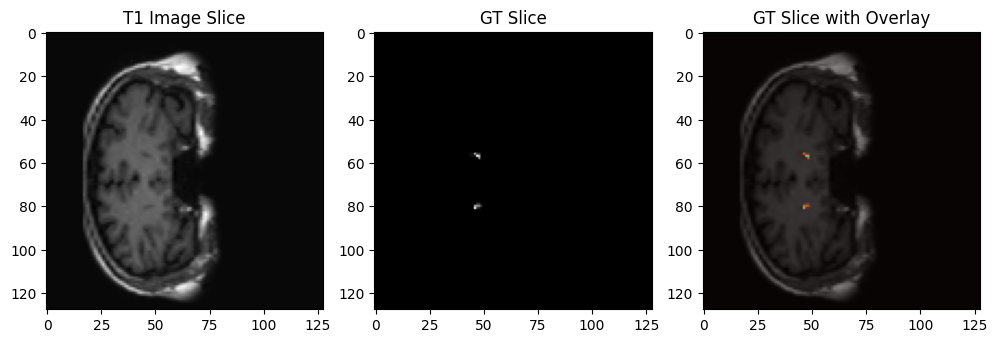

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(10, 5))

axes[0].imshow(resized_image.data[0, :, 50, :], cmap='gray')
axes[0].set_title('T1 Image Slice')

axes[1].imshow(resized_gt.data[0, :, 50, :], cmap='gray')
axes[1].set_title('GT Slice')

axes[2].imshow(resized_image.data[0, :, 50, :], cmap='gray')
axes[2].imshow(resized_gt.data[0, :, 50, :], cmap='hot', alpha=0.5)
axes[2].set_title('GT Slice with Overlay')

plt.tight_layout()